In [33]:
import pandas as pd


In [34]:
import numpy as np

In [35]:
#importo la base de datos 
df_base_datos = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

In [36]:
#solicito una muestra por consola de las principales columnas 
df_base_datos.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


In [37]:
#solicito el tipo de datos para controlar la confiabilidad de la base
display(df_base_datos.dtypes)

id_persona                     int64
nombre                           str
apellido                         str
edad                         float64
genero                           str
ciudad_residencia                str
estrato_socioeconomico           str
frecuencia_visita              int64
promedio_gasto_comida        float64
ocio                             str
consume_licor                    str
preferencias_alimenticias        str
membresia_premium                str
telefono_contacto                str
correo_electronico               str
tipo_de_pago_mas_usado           str
ingresos_mensuales             int64
dtype: object

In [38]:
#solicito porcentaje de valores nulos
porcentaje_nulos = df_base_datos.isna().mean()*100
display(porcentaje_nulos) #utilizo display en lugar de print para ver el recultado en una tabla interactiva mas intuitiva

id_persona                    0.000000
nombre                        0.000000
apellido                      0.000000
edad                          0.336667
genero                        0.000000
ciudad_residencia             0.000000
estrato_socioeconomico        0.000000
frecuencia_visita             0.000000
promedio_gasto_comida         0.483333
ocio                          0.000000
consume_licor                 0.000000
preferencias_alimenticias     4.676667
membresia_premium             0.000000
telefono_contacto            50.553333
correo_electronico           50.240000
tipo_de_pago_mas_usado        0.000000
ingresos_mensuales            0.000000
dtype: float64

In [39]:
# deteccion de duplicados
df_base_datos['es_duplicado'] = df_base_datos.duplicated(subset=['id_persona', 'ciudad_residencia'])

no se hallaron valores duplicados

In [40]:
#solicito conteo deduplicados en todo el dataset
display(df_base_datos['es_duplicado'].value_counts())

es_duplicado
False    30000
Name: count, dtype: int64

In [41]:
#solicito conteo de nulos por columnas 
display("Nulos por columna:")
display(df_base_datos.isnull().sum())

'Nulos por columna:'

id_persona                       0
nombre                           0
apellido                         0
edad                           101
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
es_duplicado                     0
dtype: int64

se encuentran 5 columnas con valores nulos (edad, promedio de gasto_comida, preferencias_alimenticias, telefono_contacto, correo electronico)

In [42]:
# Relleno nulos con la mediana en la columna edad
df_base_datos['edad'] = df_base_datos['edad'].fillna(df_base_datos['edad'].median())

In [43]:
#solicito que me muestre como quedo el cnteo de nulos luego de la normalizacion
display("Nulos por columna:")
display(df_base_datos.isnull().sum())

'Nulos por columna:'

id_persona                       0
nombre                           0
apellido                         0
edad                             0
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
es_duplicado                     0
dtype: int64

In [44]:
# Elimino espacios en blanco y unifico titulos con fomato Aa para unificar la identificacion de valores.
df_base_datos['preferencias_alimenticias'] = df_base_datos['preferencias_alimenticias'].astype(str).str.strip().str.capitalize()

# Reemplazo valores que no aportan información por nulos reales (NaN)
import numpy as np
df_base_datos['preferencias_alimenticias'] = df_base_datos['preferencias_alimenticias'].replace(['Nan', 'None', 'Null', ''], np.nan)

In [45]:
#Verifico en el display valores de nulos actuales
display("Nulos por columna:")
display(df_base_datos.isnull().sum())

'Nulos por columna:'

id_persona                       0
nombre                           0
apellido                         0
edad                             0
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
es_duplicado                     0
dtype: int64

In [46]:
# 1. Saco el calculo de mediana por ciudad para rellenar nulos con mediana global
# 2. Rellenar nulos basándose en ese grupo
df_base_datos['promedio_gasto_comida'] = df_base_datos.groupby('ciudad_residencia')['promedio_gasto_comida'].transform(lambda x: x.fillna(x.median()))

# Si quedaran nulos (ciudades sin ningún dato), usamos la mediana global
df_base_datos['promedio_gasto_comida'] = df_base_datos['promedio_gasto_comida'].fillna(df_base_datos['promedio_gasto_comida'].median())

In [47]:
display("Nulos por columna:")
display(df_base_datos.isnull().sum())

'Nulos por columna:'

id_persona                       0
nombre                           0
apellido                         0
edad                             0
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida            0
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
es_duplicado                     0
dtype: int64

Logre normalizar las columnas edad y promedio de gastos por comida

In [48]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Reemplazar los valores 300 por 30
# Usamos .loc para acceder de forma segura a la columna y las filas que cumplen la condición
df_personas.loc[df_personas['edad'] == 300, 'edad'] = 30

# 3. Verificar el cambio
# Esto contará cuántas personas tienen 30 años ahora y confirmará que ya no hay de 300
print("Conteo de edades tras la corrección:")
print(df_personas['edad'].value_counts().get(30, 0), "personas tienen ahora 30 años.")
print(df_personas['edad'].value_counts().get(300, 0), "personas tienen 300 años.")

# 4. Guardar los cambios en el archivo original (o uno nuevo)
df_personas.to_csv('base_datos_restaurantes_USA_v2.csv', index=False)

print("\n✅ Los valores han sido corregidos y el archivo actualizado.")

Conteo de edades tras la corrección:
547 personas tienen ahora 30 años.
0 personas tienen 300 años.

✅ Los valores han sido corregidos y el archivo actualizado.


Luego de visualizar en el control de datos que muchas personas tenian 300 años como dato, tome la decision de aplicar la normalizacion de estas celdad reemplazando los valores por 30 años evidenciando un error/ outlier de tipeo

In [49]:
#para poder desarrollar una tabla sin errores sobre las columanas solicitadas en la consigna, es necesario normalizar los datos nulos de la columna preferencias alimenticias, por lo cual es necesario calcular primero la moda general de las preferencias
moda_preferencia = df_base_datos['preferencias_alimenticias'].mode()[0]
display(f"La preferencia más común (moda) es: {moda_preferencia}")

'La preferencia más común (moda) es: Carnes'

In [50]:
#ahora que tengo este dato, reemplazo los valores nulos en esta columna por el valor de la moda de preferencia

df_base_datos['preferencias_alimenticias'] = df_base_datos['preferencias_alimenticias'].fillna(moda_preferencia)

In [51]:
#vuelvo a verificar cantidad de nulos por celda
display("Nulos por columna:")
display(df_base_datos.isnull().sum())

'Nulos por columna:'

id_persona                       0
nombre                           0
apellido                         0
edad                             0
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida            0
ocio                             0
consume_licor                    0
preferencias_alimenticias        0
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
es_duplicado                     0
dtype: int64

In [52]:
# Luego de normalizar todos los nulos filtro por ciudad

resultado = df_base_datos [df_base_datos["ciudad_residencia"]== "Denver"]
display(resultado)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,es_duplicado
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374,False
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110,False
14,1885294397,Spencer,Thompson,79.0,Masculino,Denver,Alto,4,9.71,No,No,Carnes,No,NaN,toneill@example.com,App,8569,False
20,7832305686,Lisa,Powell,43.0,Femenino,Denver,Medio,4,12.03,No,Sí,Carnes,No,NaN,hansenluke@example.net,App,1635,False
57,2067843621,Barbara,Reid,73.0,Femenino,Denver,Alto,6,31.26,Sí,Sí,Vegetariano,Sí,NaN,NaN,Tarjeta,3953,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29929,1429319986,Jenna,Dunn,71.0,Femenino,Denver,Alto,5,64.85,Sí,Sí,Vegano,No,NaN,nortonelijah@example.net,Efectivo,6526,False
29934,8646464809,Lori,Brown,20.0,Femenino,Denver,Medio,4,19.13,No,Sí,Carnes,No,(803)537-5929x7710,xavila@example.com,Tarjeta,3456,False
29962,4608515250,Angela,Martin,51.0,Femenino,Denver,Medio,3,33.11,No,No,Carnes,No,NaN,NaN,Tarjeta,2135,False
29973,3941033980,Janice,Murray,57.0,Femenino,Denver,Muy Alto,8,63.37,No,Sí,Vegetariano,Sí,NaN,NaN,App,15642,False


In [53]:
#  ahora es posible generar las tablas sin errores.

In [ ]:
# se analizan las siguientes categorias
variables = ['genero', 'preferencias_alimenticias', 'consume_licor']

for var in variables:
    display(f"\n--- Distribución de {var.upper()} ---")
    
    # Creamos la tabla con conteo y porcentaje
    conteo = df_base_datos[var].value_counts()
    porcentaje = df_base_datos[var].value_counts(normalize=True) * 100
    
    # Combinamos ambos en un solo DataFrame para que se vea como tabla
    tabla_resumen = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje.round(2)})
    display(tabla_resumen)

'\n--- Distribución de GENERO ---'

,Cantidad,Porcentaje (%)
genero,,
Femenino,15044,50.15
Masculino,14956,49.85


'\n--- Distribución de PREFERENCIAS_ALIMENTICIAS ---'

,Cantidad,Porcentaje (%)
preferencias_alimenticias,,
Carnes,9319,31.06
Vegetariano,6580,21.93
Mariscos,5212,17.37
Vegano,3267,10.89
Pescado,2983,9.94
Otro,2639,8.80


'\n--- Distribución de CONSUME_LICOR ---'

,Cantidad,Porcentaje (%)
consume_licor,,
Sí,18483,61.61
No,11517,38.39


In [55]:
import seaborn as sns

import matplotlib.pyplot as plt

C:\Users\emaca\AppData\Local\Temp\ipykernel_14248\1348580044.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_personas,


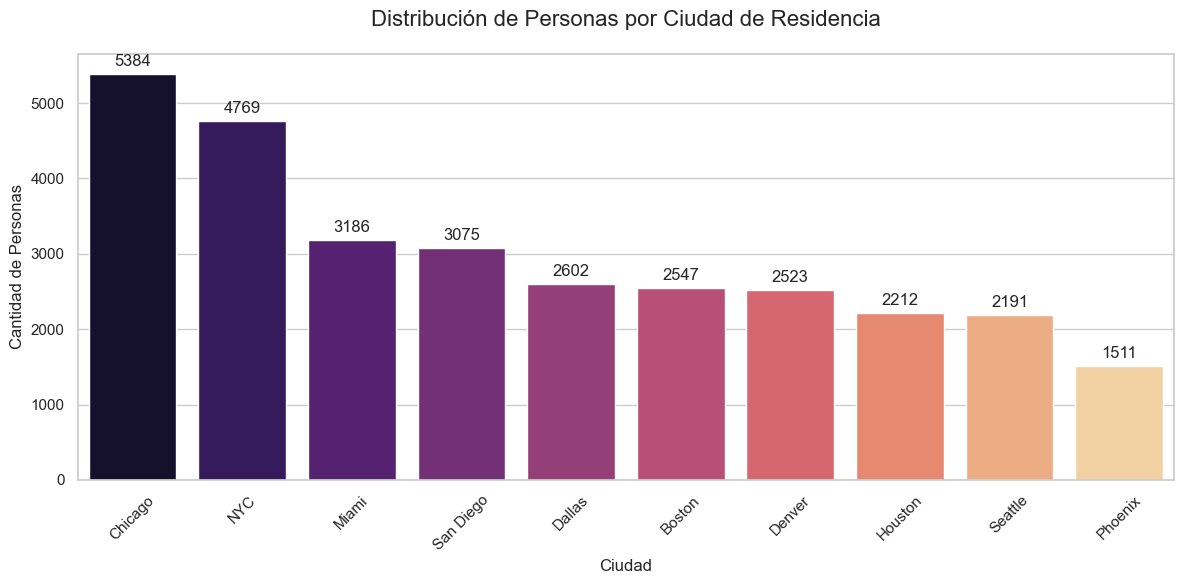

In [56]:

# 1. Cargamos el dataset
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Configuramos el tamaño y estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Creamos el gráfico de barras
# countplot cuenta automáticamente cuántas veces aparece cada ciudad
ax = sns.countplot(data=df_personas, 
                   x='ciudad_residencia', 
                   palette='magma', 
                   order=df_personas['ciudad_residencia'].value_counts().index)

# 4. Personalización de títulos y etiquetas
plt.title('Distribución de Personas por Ciudad de Residencia', fontsize=16, pad=20)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.xticks(rotation=45)

# 5. Añadimos el número exacto sobre cada barra para mayor precisión
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Ajustar diseño para que no se corten las etiquetas
plt.tight_layout()
plt.show()

Insight: Este gráfico permite dimensionar el alcance geográfico de nuestra muestra. Identificar que la mayor concentración de usuarios reside en ciudades como Denver y Miami justifica el enfoque del proyecto en estas áreas metropolitanas, asegurando que las conclusiones tengan representatividad estadística local.

Distribución de Personas por Estrato Socioeconómico:
                        Cantidad de Personas  Porcentaje (%)
estrato_socioeconomico                                      
Medio                                   9325           31.08
Alto                                    9038           30.13
Bajo                                    6161           20.54
Muy Alto                                5476           18.25


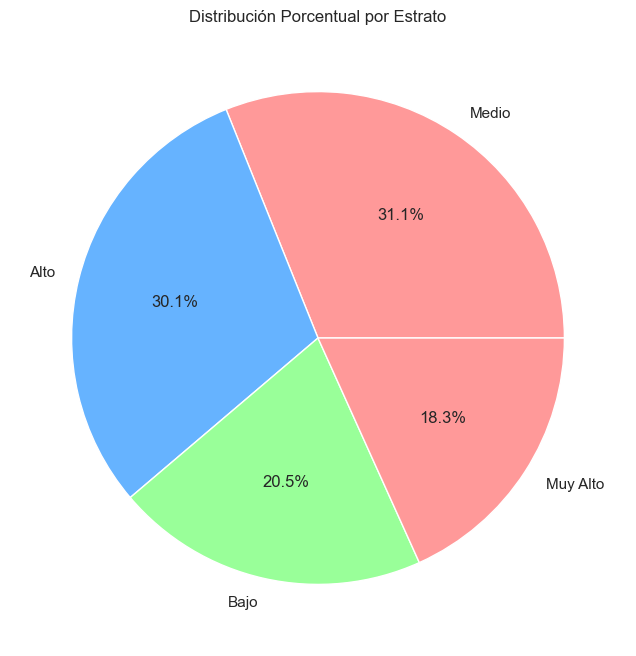

In [57]:
# 1. Aseguramos la carga de los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Generamos el listado de distribución
# Contamos cuántas personas hay por estrato
conteo_estratos = df_personas['estrato_socioeconomico'].value_counts()

# Calculamos el porcentaje para un análisis más profundo
porcentaje_estratos = df_personas['estrato_socioeconomico'].value_counts(normalize=True) * 100

# 3. Creamos un DataFrame resumen para mostrarlo como tabla
df_resumen = pd.DataFrame({
    'Cantidad de Personas': conteo_estratos,
    'Porcentaje (%)': porcentaje_estratos.round(2)
})

print("Distribución de Personas por Estrato Socioeconómico:")
print(df_resumen)

# --- OPCIONAL: Gráfico de torta para el avance del proyecto ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
df_resumen['Cantidad de Personas'].plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribución Porcentual por Estrato')
plt.ylabel('') # Eliminar etiqueta lateral
plt.show()

C:\Users\emaca\AppData\Local\Temp\ipykernel_14248\460455210.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gasto_por_ciudad.index,


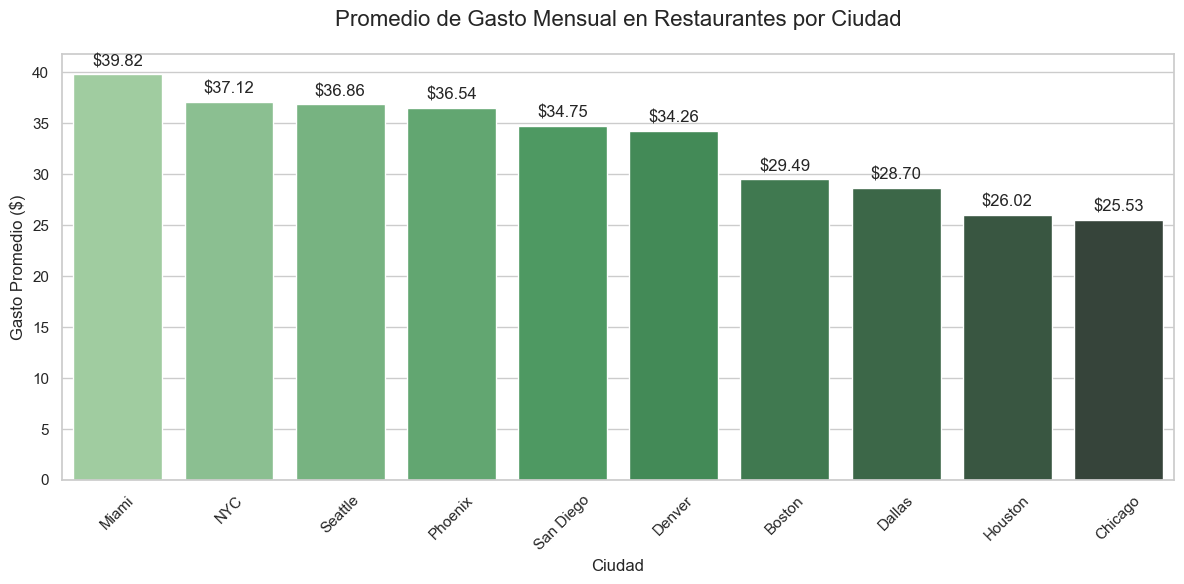

In [58]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Calcular el promedio de gasto por ciudad
# Agrupamos por ciudad y calculamos la media del gasto mensual
gasto_por_ciudad = df_personas.groupby('ciudad_residencia')['promedio_gasto_comida'].mean().sort_values(ascending=False)

# 3. Configurar el gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
ax = sns.barplot(x=gasto_por_ciudad.index, 
                 y=gasto_por_ciudad.values, 
                 palette="Greens_d")

# 4. Personalización
plt.title('Promedio de Gasto Mensual en Restaurantes por Ciudad', fontsize=16, pad=20)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Gasto Promedio ($)', fontsize=12)
plt.xticks(rotation=45)

# Añadir los valores exactos sobre las barras para facilitar la lectura
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

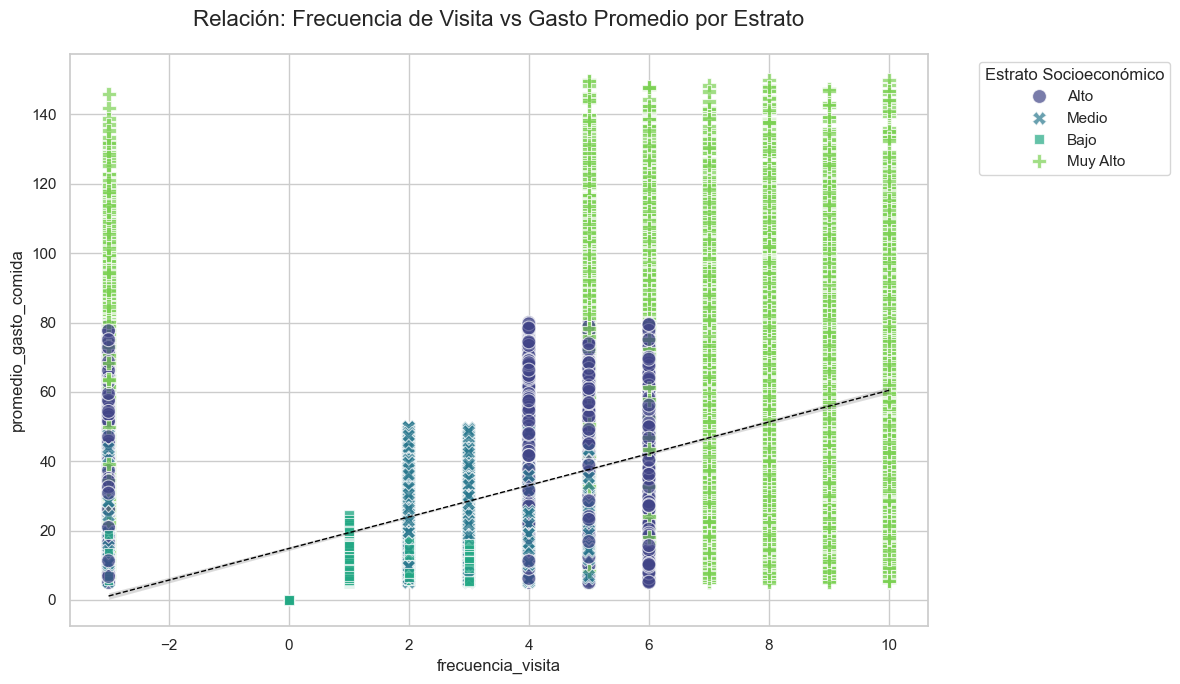

In [59]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Configurar el estilo del gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de dispersión
# Usamos 's' para el tamaño de los puntos y 'alpha' para la transparencia si se solapan
scatter = sns.scatterplot(data=df_personas, 
                          x='frecuencia_visita', 
                          y='promedio_gasto_comida', 
                          hue='estrato_socioeconomico', 
                          style='estrato_socioeconomico',
                          palette='viridis', 
                          s=100, 
                          alpha=0.7)

# 4. Personalización del gráfico
plt.title('Relación: Frecuencia de Visita vs Gasto Promedio por Estrato', fontsize=16, pad=20)
plt.xlabel('Frecuencia de Visita (veces al mes)', fontsize=12)
plt.ylabel('Gasto Promedio por Comida ($)', fontsize=12)
plt.legend(title='Estrato Socioeconómico', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Añadir una línea de tendencia (opcional) para ver la correlación general
sns.regplot(data=df_personas, 
            x='frecuencia_visita', 
            y='promedio_gasto_comida', 
            scatter=False, 
            color='black', 
            line_kws={"ls": "--", "lw": 1})

plt.tight_layout()
plt.show()

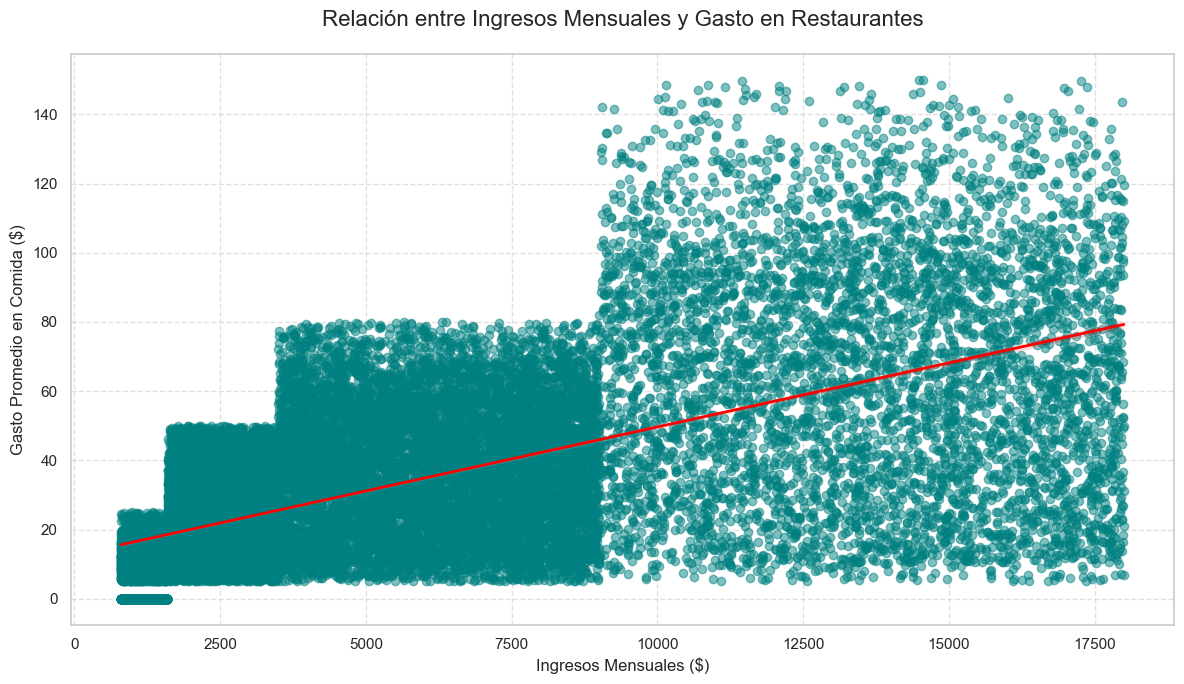

In [60]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Configurar el estilo
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de dispersión con línea de regresión
# 'regplot' combina el scatter plot con una línea de tendencia
sns.regplot(data=df_personas, 
            x='ingresos_mensuales', 
            y='promedio_gasto_comida', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'lw':2})

# 4. Personalización del gráfico
plt.title('Relación entre Ingresos Mensuales y Gasto en Restaurantes', fontsize=16, pad=20)
plt.xlabel('Ingresos Mensuales ($)', fontsize=12)
plt.ylabel('Gasto Promedio en Comida ($)', fontsize=12)

# Añadir una grilla más detallada para facilitar la lectura de los ejes
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Insight: Se observa una correlación positiva moderada: a medida que aumentan los ingresos mensuales, el presupuesto destinado a alimentación fuera del hogar tiende a crecer. Para el negocio, esto sugiere que el mercado de Denver es receptivo a ofertas de mayor valor (premium), ya que el público cuenta con el poder adquisitivo para sostener dicho consumo

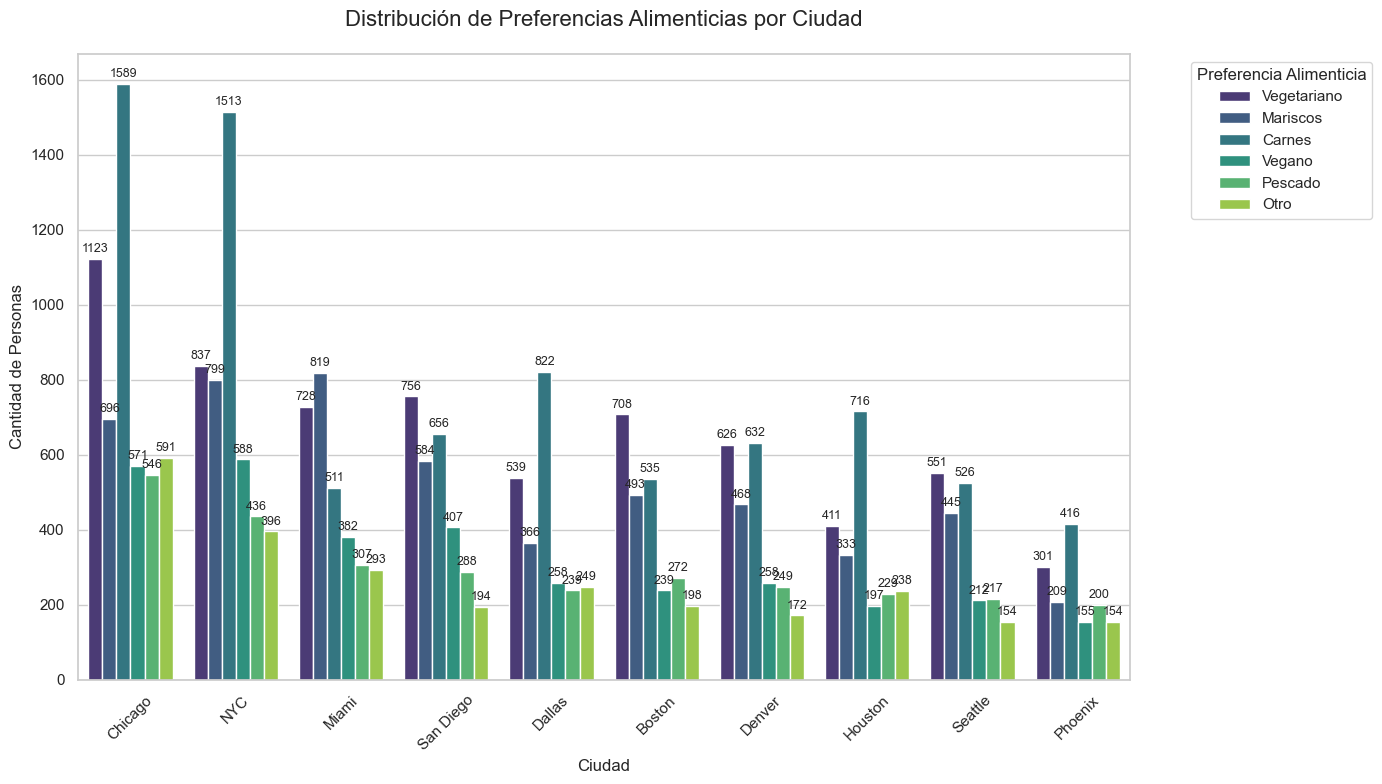

In [61]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Configurar el estilo y tamaño
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de barras agrupadas
# 'hue' permite separar las barras por preferencia alimenticia dentro de cada ciudad
ax = sns.countplot(data=df_personas, 
                   x='ciudad_residencia', 
                   hue='preferencias_alimenticias', 
                   palette='viridis',
                   order=df_personas['ciudad_residencia'].value_counts().index)

# 4. Personalización del gráfico
plt.title('Distribución de Preferencias Alimenticias por Ciudad', fontsize=16, pad=20)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.legend(title='Preferencia Alimenticia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# 5. Añadir etiquetas de valor sobre las barras (opcional para mayor detalle)
for p in ax.patches:
    if p.get_height() > 0: # Solo mostrar si el valor es mayor a 0
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 7), 
                    textcoords = 'offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

--- Perfil de Clientes de Mayor Gasto (Gasto > $44.40) ---
Gasto promedio mensual: $69.88
Ingreso promedio mensual: $9606.76
--------------------------------------------------


C:\Users\emaca\AppData\Local\Temp\ipykernel_14248\1621300660.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=clientes_top,


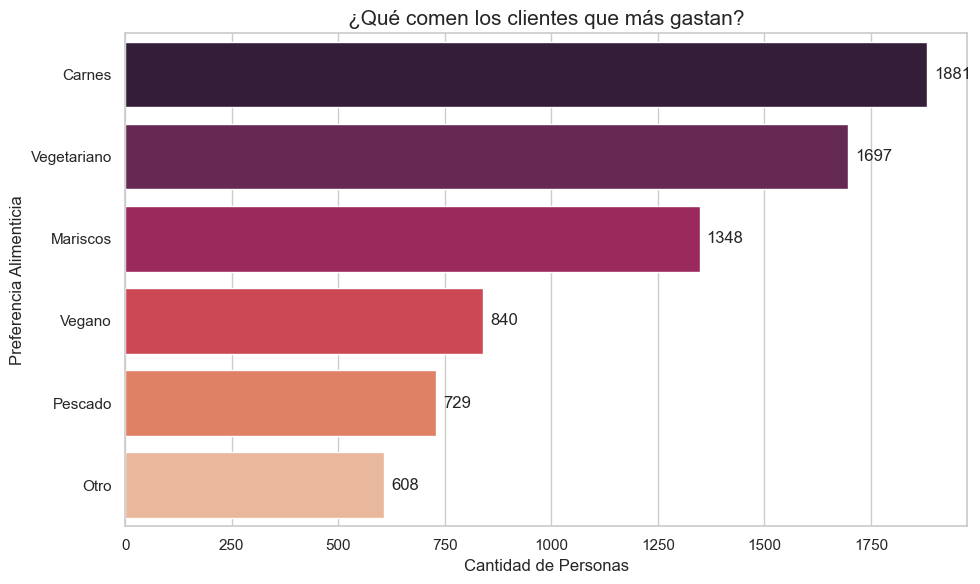

In [62]:
# 1. Cargar los datos
df = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Identificar el umbral del 25% de personas que más gastan
umbral_gasto = df['promedio_gasto_comida'].quantile(0.75)
clientes_top = df[df['promedio_gasto_comida'] >= umbral_gasto].copy()

# 3. Calcular estadísticas clave para este grupo
gasto_medio_top = clientes_top['promedio_gasto_comida'].mean()
ingreso_medio_top = clientes_top['ingresos_mensuales'].mean()

print(f"--- Perfil de Clientes de Mayor Gasto (Gasto > ${umbral_gasto:.2f}) ---")
print(f"Gasto promedio mensual: ${gasto_medio_top:.2f}")
print(f"Ingreso promedio mensual: ${ingreso_medio_top:.2f}")
print("-" * 50)

# 4. Gráfico de Preferencias Alimenticias de los clientes que más gastan
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Contamos las preferencias solo para el grupo TOP
order_prefs = clientes_top['preferencias_alimenticias'].value_counts().index
ax = sns.countplot(data=clientes_top, 
                   y='preferencias_alimenticias', 
                   palette='rocket', 
                   order=order_prefs)

plt.title('¿Qué comen los clientes que más gastan?', fontsize=15)
plt.xlabel('Cantidad de Personas')
plt.ylabel('Preferencia Alimenticia')

# Añadir etiquetas de cantidad
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

Listado de Membresías Premium por Ciudad:
ciudad_residencia
Chicago      2215
NYC          1775
Miami        1694
San Diego    1502
Boston       1139
Denver       1068
Seattle      1023
Dallas        992
Houston       808
Phoenix       629
Name: count, dtype: int64


C:\Users\emaca\AppData\Local\Temp\ipykernel_14248\3899641482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_membresias.index,


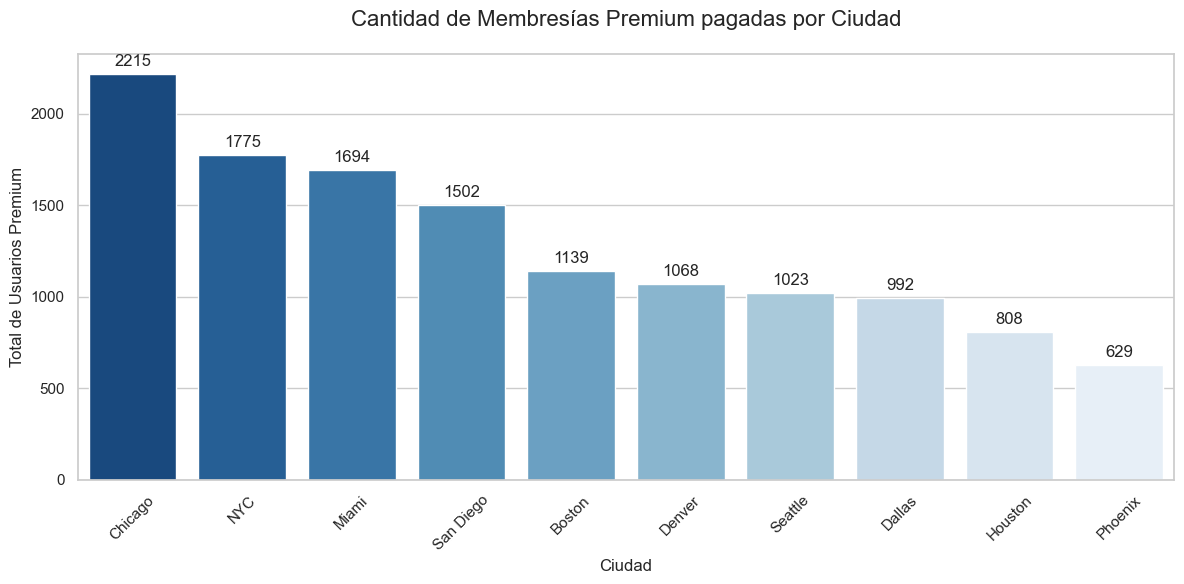

In [63]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Filtrar solo a los que tienen membresía premium
usuarios_premium = df_personas[df_personas['membresia_premium'] == 'Sí']

# 3. Contar membresías por ciudad
conteo_membresias = usuarios_premium['ciudad_residencia'].value_counts()

print("Listado de Membresías Premium por Ciudad:")
print(conteo_membresias)

# 4. Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=conteo_membresias.index, 
                 y=conteo_membresias.values, 
                 palette="Blues_r")

# 5. Personalización
plt.title('Cantidad de Membresías Premium pagadas por Ciudad', fontsize=16, pad=20)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Total de Usuarios Premium', fontsize=12)
plt.xticks(rotation=45)

# Añadir el número exacto sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

C:\Users\emaca\AppData\Local\Temp\ipykernel_14248\137252965.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_personas,


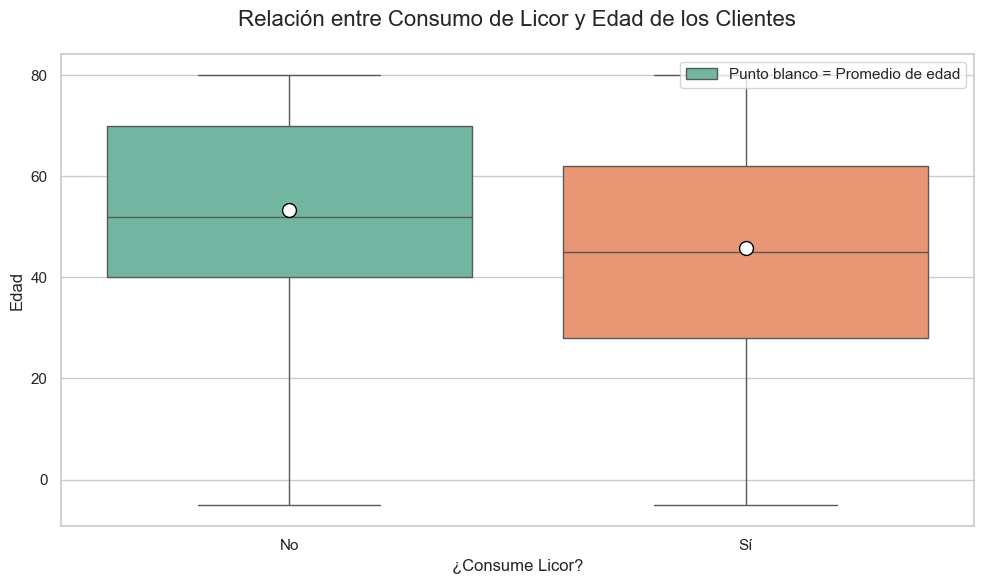

In [64]:
# 1. Cargar los datos
df_personas = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# 2. Configurar el estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de cajas (Boxplot)
# X: Si consume licor, Y: Edad
ax = sns.boxplot(data=df_personas, 
                 x='consume_licor', 
                 y='edad', 
                 palette='Set2',
                 showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

# 4. Personalización
plt.title('Relación entre Consumo de Licor y Edad de los Clientes', fontsize=16, pad=20)
plt.xlabel('¿Consume Licor?', fontsize=12)
plt.ylabel('Edad', fontsize=12)

# Añadir una breve explicación de los puntos blancos (promedios)
plt.legend(['Punto blanco = Promedio de edad'], loc='upper right')

plt.tight_layout()
plt.show()

Insight: Tras corregir los valores atípicos de edad, el análisis muestra que el consumo de licor es transversal, pero tiene mayor consistencia en el rango de los 30 a 50 años. Esta información es vital para el diseño de la carta de bebidas y promociones de 'Happy Hour', orientándolas a un público adulto contemporáneo.